<table align="left"><tr><td>
<a href="https://colab.research.google.com/github/kikim6114/nlp2026/blob/main/09.transformer_3.scratch_and_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="코랩에서 실행하기"/></a>
</td></tr></table>

In [ ]:
# Colab이나 Kaggle을 사용하는 경우가 아니면, 이 cell을 모두 주석화하여 skip할 것.
import os

repository_name = 'nlp2026'
repository_url = f'https://github.com/kikim6114/{repository_name}.git'

# 항상 루트 경로(/content/)로 이동 후 확인
%cd /content/

if not os.path.exists(repository_name):
    !git clone {repository_url}
    print(f"{repository_name} 클론 완료")
else:
    print(f"{repository_name} 폴더가 이미 존재합니다. 클론을 건너뜁니다.")
%cd nlp2026

# Transformer and Emotion Classification

## 1. Load Vocab - 샘플 입력(Batch) 준비
- `vocab`은 kowiki 말뭉치에 대한 `sentencepiece` 토큰화 모델.
- 아래에서 토큰화에 사용되는 `encode_as_pieces()` 외에도 다양한 메소드와 속성을 제공한다.
- transformer model 작성후 감정분류 문제에서도 사용됨. 

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm import tqdm

vocab_file = "./kowiki/kowiki.model"
vocab = spm.SentencePieceProcessor()
vocab.load(vocab_file)

lines = [
    "자연어처리에 관심이 많지만 좀 어렵다고 느껴집니다.",
    "너무 발전 속도가 빨라서 따라가기 벅차요.",
    "어떻게 하면 자연어처리 테크닉에 능숙할 수 있을까요?"
    ]

# text를 tensor로 변환
inputs = []
for line in lines:
    pieces = vocab.encode_as_pieces(line)
    ids = vocab.encode_as_ids(line)
    inputs.append(torch.tensor(ids))
    print(line)
    print(pieces)
    print(ids)
    print()

자연어처리에 관심이 많지만 좀 어렵다고 느껴집니다.
['▁자연', '어', '처', '리에', '▁관', '심', '이', '▁많', '지만', '▁좀', '▁어', '렵', '다고', '▁느', '껴', '집', '니다', '.']
[1147, 3680, 3899, 547, 86, 3890, 3643, 206, 100, 3586, 138, 4392, 671, 1229, 4992, 3925, 1383, 3645]

너무 발전 속도가 빨라서 따라가기 벅차요.
['▁너무', '▁발전', '▁속', '도가', '▁빨', '라', '서', '▁따라', '가', '기', '▁', '벅', '차', '요', '.']
[2805, 1074, 290, 891, 2869, 3679, 3657, 264, 3654, 3661, 3642, 5114, 3798, 3812, 3645]

어떻게 하면 자연어처리 테크닉에 능숙할 수 있을까요?
['▁어떻게', '▁하', '면', '▁자연', '어', '처', '리', '▁테', '크', '닉', '에', '▁능', '숙', '할', '▁수', '▁있을', '까', '요', '?']
[3355, 28, 3758, 1147, 3680, 3899, 3665, 522, 3795, 4383, 3646, 1047, 4198, 3807, 18, 1393, 3852, 3812, 4326]



## 2. Config

- 다양한 설정(configuration)을 `json` 파일로 저장하여 사용하기 위한 class
- <span style="color:blue">[참고] </span>[Different types of methods that can be defined in a Python class](https://www.educative.io/answers/different-types-of-methods-that-can-be-defined-in-a-python-class)

In [2]:
class Config(dict): 
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__

    @classmethod
    def load(cls, file):
        with open(file, 'r', encoding='UTF8') as f:
            config = json.loads(f.read())
            return Config(config)

- [config.json의 예 link](https://github.com/paul-hyun/transformer-evolution/blob/master/transformer/config.json)
- <span style="color: blue">[참고] </span>[json설정파일(Config) 관리 방법](https://m.blog.naver.com/wideeyed/221540272941)

In [3]:
config = Config({
    "enc_vocab_size": len(vocab),
    "dec_vocab_size": len(vocab),
    "enc_seq_len": 256,
    "dec_seq_len": 256,
    "num_layer": 6,
    "d_model": 256,
    "pad_value": 0,
    "dim_ff": 1024,
    "num_head": 4,
    "d_k": 64,
    "dropout": 0.1,
    "layer_norm_epsilon": 1e-12
})
print(config)

{'enc_vocab_size': 8007, 'dec_vocab_size': 8007, 'enc_seq_len': 256, 'dec_seq_len': 256, 'num_layer': 6, 'd_model': 256, 'pad_value': 0, 'dim_ff': 1024, 'num_head': 4, 'd_k': 64, 'dropout': 0.1, 'layer_norm_epsilon': 1e-12}


## 3. Common Classes

### Position Encoding

In [4]:
def pos_encoding_table(seq_length, d_model):
    
    def calc_angle(position, j_model):
        return position / np.power(10000, 2 * (j_model // 2) / d_model)
    def pos_angle_vector(position):
        return [calc_angle(position, j) for j in range(d_model)]

    pe = np.array([pos_angle_vector(i) for i in range(seq_length)])
    pe[:, 0::2] = np.sin(pe[:, 0::2])  # even index sin 
    pe[:, 1::2] = np.cos(pe[:, 1::2])  # odd index cos

    return pe  # numpy.ndarray

### Padding & Attention Mask

Attention mechanism에서 padding된 요소들을 attend하기 않도록 masking하기 위한 mask 계산

In [5]:
def attention_pad_mask(seq_q, seq_k, pad_value):
    batch_size, len_q = seq_q.size()  # 일반적으로 len_q = len_k
    batch_size, len_k = seq_k.size()
    pad_attn_mask = seq_k.data.eq(pad_value)
    pad_attn_mask= pad_attn_mask.unsqueeze(1).expand(batch_size, len_q, len_k)
    return pad_attn_mask

Decoder의 ‘Masked Multi Head Attention’에서 미래의 답을 훔쳐보지 못하게 하는 Mask

In [8]:
def antipeep_future_mask(seq):
    antipeep_mask = torch.ones_like(seq).unsqueeze(-1).expand(seq.size(0), seq.size(1), seq.size(1))
    antipeep_mask = antipeep_mask.triu(diagonal=1) # upper triangular part of a matrix(2-D)
    return antipeep_mask

### Scaled Dot Product Attention

In [9]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.dropout = nn.Dropout(config.dropout)
        self.scale = 1 / (self.config.d_k ** 0.5)
    
    def forward(self, Q, K, V, attn_mask):
        # Q, K, V : (batch_size, num_head, seq_length, d_k)  
        scores = torch.matmul(Q, K.transpose(-1, -2))  # scores: (batch_size, num_head, seq_length, seq_length)
        scores = scores.mul_(self.scale)
        scores.masked_fill_(attn_mask, -1e9)  # float("-inf") 도 좋으나, -1e9 도 충분
        attn_prob = nn.Softmax(dim=-1)(scores)  # (batch_size, num_head, seq_length, seq_length)
        attn_prob = self.dropout(attn_prob)
        context = torch.matmul(attn_prob, V)  # (batch_size, num_head, seq_length, d_k)
        return context, attn_prob

### Multi-Head Attention

In [10]:
class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.W_q = nn.Linear(self.config.d_model, self.config.num_head * self.config.d_k)
        self.W_k = nn.Linear(self.config.d_model, self.config.num_head * self.config.d_k)
        self.W_v = nn.Linear(self.config.d_model, self.config.num_head * self.config.d_k)
        self.scaled_dot_attn = ScaledDotProductAttention(self.config)
        self.linear = nn.Linear(self.config.num_head * self.config.d_k, self.config.d_model)
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, Q, K, V, attn_mask):
        # Q, K, V : (batch_size, seq_length, d_model)
        # attn_mask : (batch_size, seq_length, d_model)
        batch_size = Q.size(0)
        # q_s, k_s, v_s : (batch_size, num_head, seq_length, d_k)
        q_s = self.W_q(Q).view(batch_size, -1, self.config.num_head, self.config.d_k).transpose(1,2)
        k_s = self.W_k(K).view(batch_size, -1, self.config.num_head, self.config.d_k).transpose(1,2)
        v_s = self.W_v(V).view(batch_size, -1, self.config.num_head, self.config.d_k).transpose(1,2)

        # (batch_size, num_head, seq_length, seq_length)
        attn_mask = attn_mask.unsqueeze(1).repeat(1, self.config.num_head, 1, 1)

        # (batch_size, num_head, seq_length, d_k), (batch_size, num_head, seq_length, seq_length)
        context, attn_prob = self.scaled_dot_attn(q_s, k_s, v_s, attn_mask)
        # (batch_size, num_head, seq_length, h_head * d_k)
        context = context.transpose(1, 2).contiguous().view(batch_size, -1, self.config.num_head * self.config.d_k)
        # (batch_size, num_head, seq_length, e_embd)
        output = self.linear(context)
        output = self.dropout(output)
        
        return output, attn_prob  # (batch_size, seq_length, d_model), (batch_size, num_head, seq_length, seq_length)

### FeedForward

In [11]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.conv1 = nn.Conv1d(in_channels=self.config.d_model, out_channels=self.config.dim_ff, kernel_size=1)
        self.conv2 = nn.Conv1d(in_channels=self.config.dim_ff, out_channels=self.config.d_model, kernel_size=1)
        self.active = F.gelu
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, inputs):
        output = self.conv1(inputs.transpose(1, 2))  # (batch_size, dim_ff, seq_length)
        output = self.active(output)
        output = self.conv2(output).transpose(1, 2)  # (batch_size, seq_length, d_model)
        output = self.dropout(output)
        return output  # (batch_size, seq_length, d_model)

## 4. Encoder
### Encoder Layer

In [12]:
class EncoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.self_attn = MultiHeadAttention(self.config)
        self.layer_norm1 = nn.LayerNorm(self.config.d_model, eps=self.config.layer_norm_epsilon)
        self.pos_ffn = PositionwiseFeedForward(self.config)
        self.layer_norm2 = nn.LayerNorm(self.config.d_model, eps=self.config.layer_norm_epsilon)
    
    def forward(self, inputs, attn_mask):
        # (batch_size, enc_seq_len, d_model), (batch_size, num_head, enc_seq_len, enc_seq_len)
        att_outputs, attn_prob = self.self_attn(inputs, inputs, inputs, attn_mask)
        att_outputs = self.layer_norm1(inputs + att_outputs)
        # (batch_size, enc_seq_len, d_model)
        ffn_outputs = self.pos_ffn(att_outputs)
        ffn_outputs = self.layer_norm2(ffn_outputs + att_outputs)
        # (batch_size, enc_seq_len, d_model), (batch_size, num_head, enc_seq_len, enc_seq_len)
        return ffn_outputs, attn_prob

### Encoder

In [13]:
class Encoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.enc_emb = nn.Embedding(self.config.enc_vocab_size, self.config.d_model)
        pe_table = torch.FloatTensor(pos_encoding_table(self.config.enc_seq_len + 1, self.config.d_model))
        self.pos_emb = nn.Embedding.from_pretrained(pe_table, freeze=True)

        self.layers = nn.ModuleList([EncoderLayer(self.config) for _ in range(self.config.num_layer)])
    
    def forward(self, inputs):
        positions = torch.arange(inputs.size(1), device=inputs.device, dtype=inputs.dtype).expand(inputs.size(0), inputs.size(1)).contiguous() + 1
        pos_mask = inputs.eq(self.config.pad_value)
        positions.masked_fill_(pos_mask, 0)
        outputs = self.enc_emb(inputs) + self.pos_emb(positions)  # (batch_size, enc_seq_len, d_model)
        attn_mask = attention_pad_mask(inputs, inputs, self.config.pad_value) # (batch_size, enc_seq_len, enc_seq_len)
        attn_probs = []
        for layer in self.layers:
            # (batch_size, enc_seq_len, d_model), (batch_size, num_head, enc_seq_len, enc_seq_len)
            outputs, attn_prob = layer(outputs, attn_mask)
            attn_probs.append(attn_prob)
        # (batch_size, enc_seq_len, d_model), [(batch_size, num_head, enc_seq_len, enc_seq_len)]
        return outputs, attn_probs

## 5. Decoder
### Decoder Layer

In [14]:
class DecoderLayer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.self_attn = MultiHeadAttention(self.config)
        self.layer_norm1 = nn.LayerNorm(self.config.d_model, eps=self.config.layer_norm_epsilon)
        self.dec_enc_attn = MultiHeadAttention(self.config)
        self.layer_norm2 = nn.LayerNorm(self.config.d_model, eps=self.config.layer_norm_epsilon)
        self.pos_ffn = PositionwiseFeedForward(self.config)
        self.layer_norm3 = nn.LayerNorm(self.config.d_model, eps=self.config.layer_norm_epsilon)
    
    def forward(self, dec_inputs, enc_outputs, self_attn_mask, dec_enc_attn_mask):
        # (batch_size, dec_seq_len, d_model), (batch_size, num_head, dec_seq_len, dec_seq_len)
        self_att_outputs, self_attn_prob = self.self_attn(dec_inputs, dec_inputs, dec_inputs, self_attn_mask)
        self_att_outputs = self.layer_norm1(dec_inputs + self_att_outputs)
        # (batch_size, dec_seq_len, d_model), (batch_size, num_head, dec_seq_len, enc_seq_len)
        dec_enc_att_outputs, dec_enc_attn_prob = self.dec_enc_attn(self_att_outputs, enc_outputs, enc_outputs, dec_enc_attn_mask)
        dec_enc_att_outputs = self.layer_norm2(self_att_outputs + dec_enc_att_outputs)
        # (batch_size, dec_seq_len, d_model)
        ffn_outputs = self.pos_ffn(dec_enc_att_outputs)
        ffn_outputs = self.layer_norm3(dec_enc_att_outputs + ffn_outputs)
        # (batch_size, dec_seq_len, d_model), (batch_size, num_head, dec_seq_len, dec_seq_len), (batch_size, num_head, dec_seq_len, enc_seq_len)
        return ffn_outputs, self_attn_prob, dec_enc_attn_prob

### Decoder

In [15]:
""" decoder """
class Decoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.dec_emb = nn.Embedding(self.config.dec_vocab_size, self.config.d_model)
        pe_table = torch.FloatTensor(pos_encoding_table(self.config.dec_seq_len + 1, self.config.d_model))
        self.pos_emb = nn.Embedding.from_pretrained(pe_table, freeze=True)

        self.layers = nn.ModuleList([DecoderLayer(self.config) for _ in range(self.config.num_layer)])
    
    def forward(self, dec_inputs, enc_inputs, enc_outputs):
        positions = torch.arange(dec_inputs.size(1), device=dec_inputs.device, dtype=dec_inputs.dtype).expand(dec_inputs.size(0), dec_inputs.size(1)).contiguous() + 1
        pos_mask = dec_inputs.eq(self.config.pad_value)
        positions.masked_fill_(pos_mask, 0)
    
        # (batch_size, dec_seq_len, d_model)
        dec_outputs = self.dec_emb(dec_inputs) + self.pos_emb(positions)

        # (batch_size, dec_seq_len, dec_seq_len)
        dec_attn_pad_mask = attention_pad_mask(dec_inputs, dec_inputs, self.config.pad_value)
        # (batch_size, dec_seq_len, dec_seq_len)
        dec_attn_decoder_mask = antipeep_future_mask(dec_inputs)
        # (batch_size, dec_seq_len, dec_seq_len)
        dec_self_attn_mask = torch.gt((dec_attn_pad_mask + dec_attn_decoder_mask), 0)
        # (batch_size, dec_seq_len, enc_seq_len)
        dec_enc_attn_mask = attention_pad_mask(dec_inputs, enc_inputs, self.config.pad_value)

        self_attn_probs, dec_enc_attn_probs = [], []
        for layer in self.layers:
            # (batch_size, dec_seq_len, d_model), (batch_size, dec_seq_len, dec_seq_len), (batch_size, dec_seq_len, enc_seq_len)
            dec_outputs, self_attn_prob, dec_enc_attn_prob = layer(dec_outputs, enc_outputs, dec_self_attn_mask, dec_enc_attn_mask)
            self_attn_probs.append(self_attn_prob)
            dec_enc_attn_probs.append(dec_enc_attn_prob)
        # (batch_size, dec_seq_len, d_model), [(batch_size, dec_seq_len, dec_seq_len)], [(batch_size, dec_seq_len, enc_seq_len)]S
        return dec_outputs, self_attn_probs, dec_enc_attn_probs

## 6. Transformer

In [16]:
""" transformer """
class Transformer(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.encoder = Encoder(self.config)
        self.decoder = Decoder(self.config)
    
    def forward(self, enc_inputs, dec_inputs):
        # (batch_size, enc_seq_len, d_model), [(batch_size, num_head, enc_seq_len, enc_seq_len)]
        enc_outputs, enc_self_attn_probs = self.encoder(enc_inputs)
        # (batch_size, n_seq, d_model), [(batch_size, num_head, dec_seq_len, dec_seq_len)], [(batch_size, num_head, dec_seq_len, enc_seq_len)]
        dec_outputs, dec_self_attn_probs, dec_enc_attn_probs = self.decoder(dec_inputs, enc_inputs, enc_outputs)
        # (batch_size, dec_seq_len, dec_vocab_size), [(batch_size, num_head, enc_seq_len, enc_seq_len)], [(batch_size, num_head, dec_seq_len, dec_seq_len)], [(batch_size, num_head, dec_seq_len, enc_seq_len)]
        return dec_outputs, enc_self_attn_probs, dec_self_attn_probs, dec_enc_attn_probs

# Transformer를 사용한 영화리뷰 감정분석 사례

## 1. Naver 영화리뷰 감정분석 데이터셋 준비
- [참조 사이트](https://paul-hyun.github.io/preprocess-nsmc/)

In [30]:
import pandas as pd
import sys
import csv
import json
from tqdm import tqdm

In [18]:
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt -P C:\GoogleDrive\@teaching\NLP\scratch2\ratings
!wget https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt -P C:\GoogleDrive\@teaching\NLP\scratch2\ratings

--2024-01-26 23:16:50--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14628807 (14M) [text/plain]
Saving to: 'C:/GoogleDrive/@teaching/NLP/scratch2/ratings/ratings_train.txt.1'

     0K .......... .......... .......... .......... ..........  0% 2.35M 6s
    50K .......... .......... .......... .......... ..........  0% 69.5M 3s
   100K .......... .......... .......... .......... ..........  1% 41.4M 2s
   150K .......... .......... .......... .......... ..........  1% 85.1M 2s
   200K .......... .......... .......... .......... ..........  1%  102M 1s
   250K .......... .......... .......... .......... ..........  2% 46.6M 1s
   300K .......... .......... .......... .......... .......... 

--2024-01-26 23:16:52--  https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4893335 (4.7M) [text/plain]
Saving to: 'C:/GoogleDrive/@teaching/NLP/scratch2/ratings/ratings_test.txt.1'

     0K .......... .......... .......... .......... ..........  1% 10.4M 0s
    50K .......... .......... .......... .......... ..........  2% 16.3M 0s
   100K .......... .......... .......... .......... ..........  3% 12.4M 0s
   150K .......... .......... .......... .......... ..........  4% 12.1M 0s
   200K .......... .......... .......... .......... ..........  5% 12.4M 0s
   250K .......... .......... .......... .......... ..........  6% 12.3M 0s
   300K .......... .......... .......... .......... ..........  7

In [19]:
""" train data 준비 """
def prepare_train(vocab, infile, outfile):
    df = pd.read_csv(infile, sep="\t", engine="python")
    with open(outfile, "w") as f:
        for index, row in df.iterrows():
            document = row["document"]
            if type(document) != str:
                continue
            instance = { "id": row["id"], "doc": vocab.encode_as_pieces(document), "label": row["label"] }
            f.write(json.dumps(instance))
            f.write("\n")

In [20]:
prepare_train(vocab, "./ratings/ratings_train.txt", "./ratings/ratings_train.json")
prepare_train(vocab, "./ratings/ratings_test.txt", "./ratings/ratings_test.json")

## 2. Model

In [24]:
""" 네이버 Movie Review 분류 """
class MovieClassification(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = Transformer(self.config)
        self.projection = nn.Linear(self.config.d_model, self.config.n_output, bias=False)
    
    def forward(self, enc_inputs, dec_inputs):
        # (bs, n_dec_seq, d_model), [(bs, n_head, n_enc_seq, n_enc_seq)], [(bs, n_head, n_dec_seq, n_dec_seq)], [(bs, n_head, n_dec_seq, n_enc_seq)]
        dec_outputs, enc_self_attn_probs, dec_self_attn_probs, dec_enc_attn_probs = self.transformer(enc_inputs, dec_inputs)
        # (bs, d_model)
        dec_outputs, _ = torch.max(dec_outputs, dim=1)
        # (bs, n_output)
        logits = self.projection(dec_outputs)
        # (bs, n_output), [(bs, n_head, n_enc_seq, n_enc_seq)], [(bs, n_head, n_dec_seq, n_dec_seq)], [(bs, n_head, n_dec_seq, n_enc_seq)]
        return logits, enc_self_attn_probs, dec_self_attn_probs, dec_enc_attn_probs

## 3. Dataset

#### Dataset

In [25]:
""" 영화 분류 데이터셋 """
class MovieDataSet(torch.utils.data.Dataset):
    def __init__(self, vocab, infile):
        self.vocab = vocab
        self.labels = []
        self.sentences = []

        line_cnt = 0
        with open(infile, "r") as f:
            for line in f:
                line_cnt += 1

        with open(infile, "r") as f:
            for i, line in enumerate(tqdm(f, total=line_cnt, desc=f"Loading {infile}", unit=" lines")):
                data = json.loads(line)
                self.labels.append(data["label"])
                self.sentences.append([vocab.piece_to_id(p) for p in data["doc"]])
    
    def __len__(self):
        assert len(self.labels) == len(self.sentences)
        return len(self.labels)
    
    def __getitem__(self, item):
        return (torch.tensor(self.labels[item]),
                torch.tensor(self.sentences[item]),
                torch.tensor([self.vocab.piece_to_id("[BOS]")]))

#### collate_fn

In [26]:
""" movie data collate_fn """
def movie_collate_fn(inputs):
    labels, enc_inputs, dec_inputs = list(zip(*inputs))

    enc_inputs = torch.nn.utils.rnn.pad_sequence(enc_inputs, batch_first=True, pad_value=0)
    dec_inputs = torch.nn.utils.rnn.pad_sequence(dec_inputs, batch_first=True, pad_value=0)

    batch = [
        torch.stack(labels, dim=0),
        enc_inputs,
        dec_inputs,
    ]
    return batch

#### DataLoader

In [31]:
batch_size = 128
train_dataset = MovieDataSet(vocab, "./ratings/ratings_train.json")
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=movie_collate_fn)
test_dataset = MovieDataSet(vocab, "./ratings/ratings_test.json")
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=movie_collate_fn)

Loading ./ratings/ratings_test.json: 100%|████████████████████████████████| 49997/49997 [00:01<00:00, 41427.04 lines/s]


## 4. Evaluation

In [32]:
""" 모델 epoch 평가 """
def eval_epoch(config, model, data_loader):
    matchs = []
    model.eval()

    n_word_total = 0
    n_correct_total = 0
    with tqdm(total=len(data_loader), desc=f"Valid") as pbar:
        for i, value in enumerate(data_loader):
            labels, enc_inputs, dec_inputs = map(lambda v: v.to(config.device), value)

            outputs = model(enc_inputs, dec_inputs)
            logits = outputs[0]
            _, indices = logits.max(1)

            match = torch.eq(indices, labels).detach()
            matchs.extend(match.cpu())
            accuracy = np.sum(matchs) / len(matchs) if 0 < len(matchs) else 0

            pbar.update(1)
            pbar.set_postfix_str(f"Acc: {accuracy:.3f}")
    return np.sum(matchs) / len(matchs) if 0 < len(matchs) else 0

## 5. Train

In [33]:
""" 모델 epoch 학습 """
def train_epoch(config, epoch, model, criterion, optimizer, train_loader):
    losses = []
    model.train()

    with tqdm(total=len(train_loader), desc=f"Train {epoch}") as pbar:
        for i, value in enumerate(train_loader):
            labels, enc_inputs, dec_inputs = map(lambda v: v.to(config.device), value)

            optimizer.zero_grad()
            outputs = model(enc_inputs, dec_inputs)
            logits = outputs[0]

            loss = criterion(logits, labels)
            loss_val = loss.item()
            losses.append(loss_val)

            loss.backward()
            optimizer.step()

            pbar.update(1)
            pbar.set_postfix_str(f"Loss: {loss_val:.3f} ({np.mean(losses):.3f})")
    return np.mean(losses)

In [34]:
config.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
config.n_output = 2
print(config)

learning_rate = 5e-5
n_epoch = 10

{'enc_vocab_size': 8007, 'dec_vocab_size': 8007, 'enc_seq_len': 256, 'dec_seq_len': 256, 'num_layer': 6, 'd_model': 256, 'padding': 0, 'dim_ff': 1024, 'num_head': 4, 'd_k': 64, 'dropout': 0.1, 'layer_norm_epsilon': 1e-12, 'device': device(type='cuda'), 'n_output': 2}


In [37]:
model = MovieClassification(config)
model.to(config.device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

losses, scores = [], []
for epoch in range(n_epoch):
    loss = train_epoch(config, epoch, model, criterion, optimizer, train_loader)
    score = eval_epoch(config, model, test_loader)

    losses.append(loss)
    scores.append(score)

Valid: 100%|█████████████████████████████████████████████████████████████| 391/391 [02:07<00:00,  3.07it/s, Acc: 0.832]


## 6. Result

,loss,score
0,0.480897,0.804328
1,0.401763,0.817649
2,0.373606,0.821869
3,0.354048,0.824849
4,0.334479,0.825970
5,0.315047,0.831870
6,0.292919,0.832310
7,0.271117,0.834950
8,0.248307,0.835290
9,0.225665,0.832250


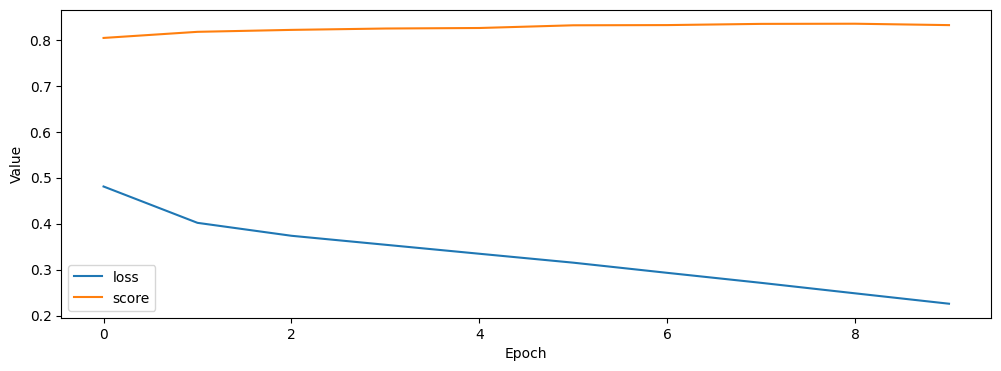

In [39]:
import matplotlib.pyplot as plt 

# table
data = {
    "loss": losses,
    "score": scores
}
df = pd.DataFrame(data)
display(df)

# graph
plt.figure(figsize=[12, 4])
plt.plot(losses, label="loss")
plt.plot(scores, label="score")
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.show()